In [1]:
import scipy
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import csc_matrix, csr_matrix, coo_matrix
from scipy.sparse.linalg import aslinearoperator

np.set_printoptions(linewidth=100000)
np.set_printoptions(precision=5)

from pyiga import bspline, assemble, vform, geometry, vis, solvers, topology, bspline_cy


In [166]:
def mp_resPois(MP, uh, f=0., nu=1., MaT=(0.,0.), divMaT =0., neu_data={}, **kwargs):
    if isinstance(nu,(int,float)):
        nu={d:nu for d in MP.mesh.domains}
    if isinstance(f,(int,float)):
        f={d:f for d in MP.mesh.domains}
    if isinstance(MaT,(tuple,list,set,np.ndarray)):
        assert len(MaT)==2, 'coefficient has wrong dimension'
        if all([isinstance(m,(int,float)) for m in MaT]):
            MaT={d:MaT for d in MP.mesh.domains}

    if MP.coupled and len(uh)==MP.nDofs:
        uh_loc = MP.Basis@uh
    elif len(uh)==MP.N_ofs[-1]:
        uh_loc = uh
    else:
        raise Exception("Dimension of solution vector is incompatible!")
    uh_per_patch = dict()

    indicator = np.zeros(MP.mesh.numpatches)
    
    #residual
    for p, ((kvs, geo), _) in enumerate(MP.mesh.patches):
        h = np.linalg.norm([kv.meshsize_max()*(b-a) for kv,(a,b) in zip(kvs,geo.bounding_box(full=True))])
        uh_per_patch[p] = uh_loc[np.arange(MP.N[p]) + MP.N_ofs[p]]   #cache Spline Function on patch p
        kvs0 = tuple([bspline.KnotVector(kv.mesh, 0) for kv in kvs])
        u_func = geometry.BSplineFunc(kvs, uh_per_patch[p])
        indicator[p] = h**2 * np.sum(assemble.assemble('((f + div(nu*grad(uh)))**2 * v) * dx', kvs=kvs0, geo=geo, physical=True,
                                                       nu=nu[MP.mesh.patch_domains[p]], f=f[MP.mesh.patch_domains[p]],uh=u_func,**kwargs))
    #interface flux
    for i,((p1,b1,_), (p2,b2,_), flip) in enumerate(MP.intfs):
        ((kvs1, geo1), _), ((kvs2, geo2), _) = MP.mesh.patches[p1], MP.mesh.patches[p2]
        bdspec1, bdspec2 = bspline._parse_bdspec(b1,2), bspline._parse_bdspec(b2,2)
        bkv1, bkv2 = assemble.boundary_kv(kvs1, bdspec1), assemble.boundary_kv(kvs2, bdspec2)
        geo = geo2.boundary(bdspec2)
        kv0 = tuple([bspline.KnotVector(kv.mesh, 0) for kv in bkv2])
        h = bkv2[0].meshsize_max()*np.linalg.norm([b-a for a,b in geo.bounding_box(full=True)])

        uh1_grad = geometry.BSplineFunc(kvs1, uh_loc[MP.N_ofs[p1]:MP.N_ofs[p1+1]]).transformed_jacobian(geo1).boundary(bdspec1, flip=flip) 
        uh2_grad = geometry.BSplineFunc(kvs2, uh_loc[MP.N_ofs[p2]:MP.N_ofs[p2+1]]).transformed_jacobian(geo2).boundary(bdspec2)            
        J = np.sum(assemble.assemble('((inner((nu1 * uh1_grad + Ma1) - (nu2 * uh2_grad + Ma2), n) )**2 * v ) * ds', kv0, geo=geo, physical=True,
                                     nu1=nu[MP.mesh.patch_domains[p1]], nu2=nu[MP.mesh.patch_domains[p2]], uh1_grad=uh1_grad, uh2_grad=uh2_grad,
                                     Ma1=MaT[MP.mesh.patch_domains[p1]], Ma2=MaT[MP.mesh.patch_domains[p2]], **kwargs))
        indicator[p1] += 0.5 * h * J
        indicator[p2] += 0.5 * h * J
        
    #Neumann flux
    for bd in neu_data:
        g = neu_data[bd]
        for (p,b) in MP.mesh.outer_boundaries[bd]:
            ((kvs, geo), _) = MP.mesh.patches[p]
            bdspec = bspline._parse_bdspec(b,2)
            bkv = assemble.boundary_kv(kvs, bdspec)
            h = bkv[0].meshsize_max() * np.linalg.norm([b - a for a, b in geo_b.bounding_box(full=True)])
            kv0 = tuple([bspline.KnotVector(kv.mesh, 0) for kv in bkv])
            geo_b = geo.boundary(bdspec)
            uh_grad = geometry.BSplineFunc(kvs, uh_per_patch[p]).transformed_jacobian(geo).boundary(bdspec)
            J = np.sum(assemble.assemble('((inner(nu * uh_grad + Ma, n) - g)**2 * v ) * ds', kv0 ,geo=geo_b,Ma=MaT[MP.mesh.patch_domains[p]],
                                         nu=nu[MP.mesh.patch_domains[p]],g=g, uh_grad=uh_grad, **kwargs))
            indicator[p] += h * J
            
    return np.sqrt(indicator)

In [167]:
kvs=2*(bspline.make_knots(5,0.0,1.0,10),)
geo1=geometry.unit_square()
geo2=geometry.unit_square().translate((1,0))
M = topology.PatchMesh([(kvs,geo1),(kvs,geo2)])
M.set_domain_id({1:{1}})
MP = assemble.Multipatch(M, automatch=True)

setting up constraints took 0.003116130828857422 seconds.
Basis setup took 0.0027878284454345703 seconds


In [168]:
u = np.vectorize(lambda x, y: x**2 if x < 1 else (x-2)**2)

In [169]:
uh = MP.L2projection(u)

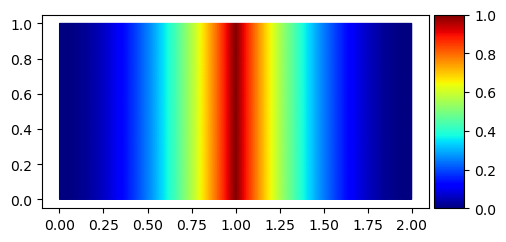

In [170]:
MP.plot(uh);

In [171]:
mp_resPois(MP, uh, nu={0:1.,1:1.})

[0.08 0.08]


array([0.93808, 0.93808])